In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Tested on Nebius.AI:
   - GPU: 1xH100 80GB SXM (NVIDIA® H100 NVLink with Intel Sapphire Rapids)
   - Host System: Ubuntu 22.04 LTS for NVIDIA® GPUs (CUDA® 12)

### H100 NF4 Inference Benchmark

In [2]:
data_path = "H100_shfl_sync_3_runs/benchmark_results"

In [3]:
raw_data = []
runs = os.listdir(data_path)
for run in runs:
    if not os.path.isdir(os.path.join(data_path,run)): continue
    branches = os.listdir(os.path.join(data_path, run))
    for branch in branches:
        path_to_models = os.path.join(data_path, run, branch)
        if not os.path.isdir(path_to_models): continue
        models = os.listdir(path_to_models)
        for model in models:
            data_files = glob.glob(os.path.join(data_path, run, branch, model, "*.json"))
            for filepath in data_files:
                # benchmark-nf4-bsz-1-isz-512-osz-64-iter10-wrmup-1-blksz64
                experiment = os.path.basename(filepath)[:-5].split("-")
                raw_data.append({
                    "run": run,
                    "branch": branch,
                    "file": filepath,
                    "model": model,
                    "config": experiment[1],
                    "batch_size": experiment[3],
                    "input_size": experiment[5],
                    "output_size": experiment[7],
                    "iterations": experiment[9],
                    "warmup": experiment[11],
                    "blocksize": experiment[13] if 13<len(experiment) else -1,
                })

metadata_df = pd.DataFrame(raw_data)
metadata_df

,run,branch,file,model,config,batch_size,input_size,output_size,iterations,warmup,blocksize
0,run_1,cuda-branchless-dequantization-shfl-sync,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,1,2048,128,10,10,64
1,run_1,cuda-branchless-dequantization-shfl-sync,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,16,2048,128,10,10,64
2,run_1,cuda-branchless-dequantization-shfl-sync,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,4,2048,128,10,10,64
3,run_1,cuda-branchless-dequantization-shfl-sync,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,8,2048,128,10,10,64
4,run_1,main,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,1,2048,128,10,10,64
5,run_1,main,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,16,2048,128,10,10,64
6,run_1,main,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,4,2048,128,10,10,64
7,run_1,main,H100_shfl_sync_3_runs/benchmark_results\run_1\...,Llama-3.1-70B,nf4,8,2048,128,10,10,64
8,run_2,cuda-branchless-dequantization-shfl-sync,H100_shfl_sync_3_runs/benchmark_results\run_2\...,Llama-3.1-70B,nf4,1,2048,128,10,10,64
9,run_2,cuda-branchless-dequantization-shfl-sync,H100_shfl_sync_3_runs/benchmark_results\run_2\...,Llama-3.1-70B,nf4,16,2048,128,10,10,64


In [4]:
dfs = []
for _, row in metadata_df.iterrows():
    dff = pd.read_json(row["file"]).T
    dff["model"] = row["model"]
    dff["branch"] = row["branch"]
    dff["config"] = row["config"]
    dff["batch_size"] = int(row["batch_size"])
    dff["run"] = row["run"]
    dff["input_size"] = row["input_size"]
    dff["output_size"] = row["output_size"]
    dfs.append(dff)
df = pd.concat(dfs)

def expand_dict_column(df, col):
    expanded = df[col].apply(pd.Series)
    if expanded is not None:
        keys = keys_to_expand.get(col, None)
        if keys:
            expanded = expanded[keys]
        expanded = expanded.add_prefix(f"{col}_")
        return expanded
    return None

# apply the function to all columns that contain dicts
expanded_parts = []
keys_to_expand = {"latency": ["total", "mean", "p50", "stdev_"],}
exclude = ["memory", "energy", "efficiency"]
for col in df.drop(columns=exclude).columns:
    if df[col].apply(lambda x: isinstance(x, dict)).any():
        expanded = expand_dict_column(df, col)
        expanded_parts.append(expanded)

OTHER_BRANCH = "cuda-branchless-dequantization-shfl-sync"
BASELINE_BRANCH = "main"

# merge all expansions with the original df
df_final = pd.concat([df.drop(columns=exclude), *expanded_parts], axis=1)
mask = df_final.branch.isin([OTHER_BRANCH, BASELINE_BRANCH])

In [5]:
# get a dataframe for statistical analysis
df_final["latency_values"] = df_final.latency.apply(lambda d: d.get('values'))
index_mask = df_final.index.isin(["prefill", "decode"])
stability_df = df_final[mask].loc[index_mask].reset_index()
stability_df = stability_df.groupby(["model", "input_size", "output_size", 'config', 'branch', "batch_size", "index", "run"])[["latency_values"]].first()
stability_df = stability_df.sort_index(level=4)
stability_df.head()

latency_values
model         input_size output_size config branch                                   batch_size index   run                                                     
Llama-3.1-70B 2048       128         nf4    cuda-branchless-dequantization-shfl-sync 1          decode  run_1  [14.173002435302735, 13.969967279052735, 13.93...
                                                                                                        run_2  [14.693162493896484, 14.676662493896485, 14.62...
                                                                                                        run_3  [14.497443719482423, 14.540049188232421, 14.47...
                                                                                                prefill run_1  [0.695165710449218, 0.696146423339843, 0.69581...
                                                                                                        run_2  [0.696556640625, 0.698337341308593, 0.70019866...

In [6]:
cols = ["latency_total", "latency_mean", "latency_p50", "throughput_value"]
data = df_final[mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "batch_size", "index", "run", 'branch'])[cols].first()
baseline = data.xs(BASELINE_BRANCH, level=7)
improved = data.xs(OTHER_BRANCH, level=7)

# less is better for latency
diff = (baseline-improved)/baseline * 100

# higher is better for throughput
diff["throughput_value"] *= -1

index_mask = diff.index.get_level_values(5).isin(["prefill", "decode"])

diff = diff.add_suffix("_diff_%")

# aggregate over all runs (mean)
run_agg_diff = diff[index_mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "index", "batch_size"])[diff.columns].mean().sort_index(level=4)
run_agg_diff.round(3)

latency_total_diff_%  \
model         input_size output_size config index   batch_size                         
Llama-3.1-70B 2048       128         nf4    decode  1                         -2.101   
                                                    4                         22.595   
                                                    8                         22.711   
                                                    16                        21.557   
                                            prefill 1                          9.189   
                                                    4                          3.173   
                                                    8                          1.695   
                                                    16                         0.846   

                                                                latency_mean_diff_%  \
model         input_size output_size config index   batch_size                        
Llama-3.1-70B 2048       128         nf4    decode  1                        -2.101   
                                                    4                        22.595   
                                                    8                        22.711   
                                                    16                       21.557   
                                            prefill 1                         9.189   
                                                    4                         3.173   
                                                    8                         1.695   
                                                    16                        0.846   

                                                                latency_p50_diff_%  \
model         input_size output_size config index   batch_size                       
Llama-3.1-70B 2048       128         nf4    decode  1                       -2.070   
                                                    4                       22.645   
                                                    8                       22.721   
                                                    16                      21.531   
                                            prefill 1                        9.188   
                                                    4                        3.186   
                                                    8                        1.683   
                                                    16                       0.831   

                                                                throughput_value_diff_%  
model         input_size output_size config index   batch_size                           
Llama-3.1-70B 2048       128         nf4    decode  1                            -2.058  
                                                    4                            29.193  
                                                    8                            29.391  
                                                    16                           27.483  
                                            prefill 1                            10.123  
                                                    4                             3.277  
                                                    8                             1.725  
                                                    16                            0.854

#### Stability Checking

##### Stability Across Runs (Levene's Test)

In [7]:
stability_df.head()

latency_values
model         input_size output_size config branch                                   batch_size index   run                                                     
Llama-3.1-70B 2048       128         nf4    cuda-branchless-dequantization-shfl-sync 1          decode  run_1  [14.173002435302735, 13.969967279052735, 13.93...
                                                                                                        run_2  [14.693162493896484, 14.676662493896485, 14.62...
                                                                                                        run_3  [14.497443719482423, 14.540049188232421, 14.47...
                                                                                                prefill run_1  [0.695165710449218, 0.696146423339843, 0.69581...
                                                                                                        run_2  [0.696556640625, 0.698337341308593, 0.70019866...

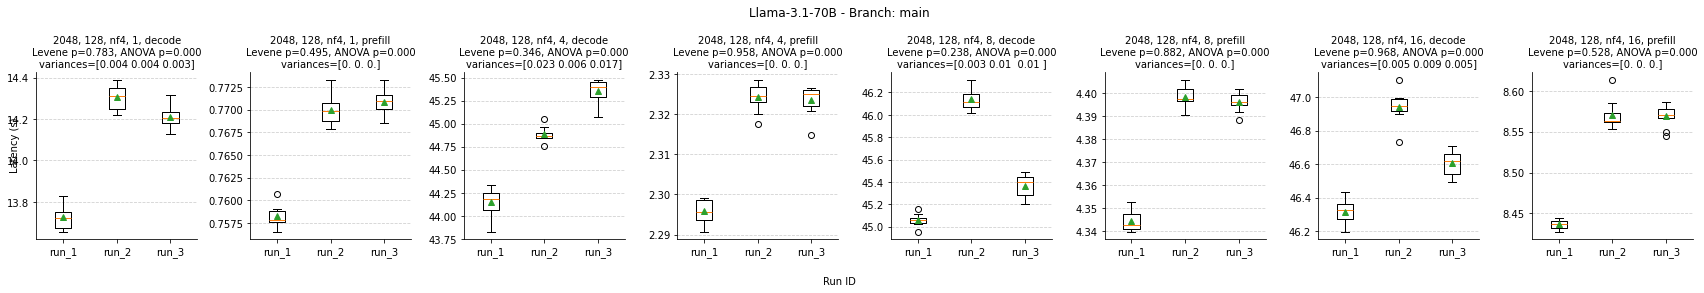

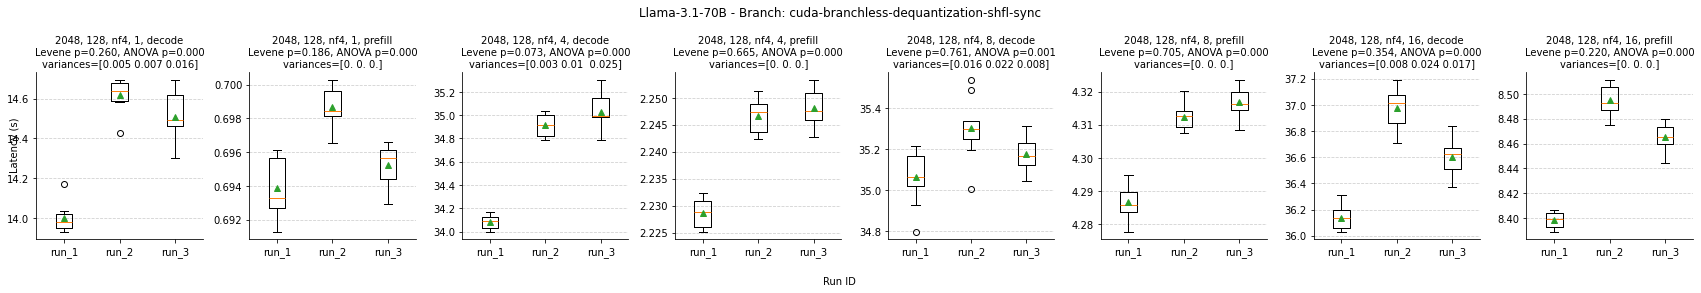

In [8]:
# get all run ids
run_ids = diff.index.get_level_values(6).unique()
branches = [BASELINE_BRANCH, OTHER_BRANCH]
for branch in branches:
    branch_df = stability_df.xs(branch, level=4)

    nrows = 1
    ncols = branch_df.shape[0]//len(run_ids)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 4))

    # each unique configuration of (model, input_size, output_size, config, batch_size, index) will have N runs
    # do levene test on these runs
    for i in range(branch_df.shape[0]//len(run_ids)):
        # the current index points to a configuraton of (model	input_size	output_size	config	batch_size	index)
        runs = [branch_df.xs(run_id, level=6).iloc[i]["latency_values"] for run_id in run_ids]
        sample_variances = np.round([np.var(r, ddof=1) for r in runs], 3)
        index = branch_df.xs(run_ids[0], level=6).iloc[i].to_frame().T.index.tolist()[0]
        _, p_value = stats.levene(*runs)
        _, anova_p_value = stats.f_oneway(*runs)
        rejection_status = "reject" if p_value < 0.05 else "no significant difference"
        # print(f"\t {str(index):55}: {rejection_status:30}, {p_value:0.7f}")
        if rejection_status == "reject":
            print("Test", index, "is rejected. Variances:", sample_variances)

        model_name, *index = index
        index = ', '.join(map(str, index))
        ax = axes[i]
        ax.boxplot(runs, labels=run_ids, showmeans=True)
        ax.set_title(
            f"{index}\n"
            f"Levene p={p_value:.3f}, ANOVA p={anova_p_value:.3f}\n"
            f"variances={sample_variances}", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"{model_name} - Branch: {branch}")
    fig.supxlabel("Run ID", fontsize=10)
    fig.supylabel("Latency (s)", fontsize=10)
    plt.tight_layout()
    plt.show()

Observations and notes:
- Levene's test assess the equality of variances between two or more groups of a measured variable
- ANOVA determines if there are significant differences between the means of three or more independent groups. ANOVA is too senstive for this benchmark. 
- Since the variances between runs are almost identical (levene's p >= 0.05) and variance is low, the benchmark is stable enough.
- Be careful of the range of the y axis of each plot because it might trick you.

##### Baseline vs Improved (Paired t-tests per Run)

In [9]:
# run a PAIRED t-test between different branches
column = "latency_values"

baseline_s_df = stability_df.xs(BASELINE_BRANCH, level=4)
improved_s_df = stability_df.xs(OTHER_BRANCH, level=4)

for run_id in run_ids:
    print(run_id)
    baseline_run = baseline_s_df.xs(run_id, level=6)
    improved_run = improved_s_df.xs(run_id, level=6)
    assert (improved_run.index == baseline_run.index).all()
    for config_idx in range(improved_s_df.shape[0]//len(run_ids)):
        baseline_config_data = baseline_run.iloc[config_idx]["latency_values"]
        improved_config_data = improved_run.iloc[config_idx]["latency_values"]
        index = baseline_s_df.xs(run_ids[0], level=6).iloc[config_idx].to_frame().T.index.tolist()[0]
        index = ', '.join(map(str,index))

        # the improved should always be better
        # so set alternative hypotthesis to be less
        t_stat, p_value = stats.ttest_rel(baseline_config_data, improved_config_data, alternative='less')

        rejection_status = " ~ no significant difference ~ " if p_value < 0.05 else "significant difference!"
        # print(index, rejection_status, stats)
        m1 = np.mean(baseline_config_data)
        m2 = np.mean(improved_config_data)
        print(
            f"\t {index:42}: baseline={m1:06.03f}, "
            f"improved={m2:06.03f}, "
            f"percentage_diff={(m1-m2)/m1*100:05.02f}%, "
            f"result= {rejection_status:25}"
        )

    print()

run_1
	 Llama-3.1-70B, 2048, 128, nf4, 1, decode  : baseline=13.725, improved=13.999, percentage_diff=-1.99%, result=  ~ no significant difference ~ 
	 Llama-3.1-70B, 2048, 128, nf4, 1, prefill : baseline=00.758, improved=00.694, percentage_diff=08.49%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 4, decode  : baseline=44.149, improved=34.083, percentage_diff=22.80%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 4, prefill : baseline=02.296, improved=02.229, percentage_diff=02.93%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 8, decode  : baseline=45.058, improved=35.064, percentage_diff=22.18%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 8, prefill : baseline=04.344, improved=04.287, percentage_diff=01.32%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 16, decode : baseline=46.317, improved=36.137, percentage_diff=21.98%, result= significant difference!  
	 Llama-3.1-70B, 2048,

Observation: There is a statistically significant improvement. 

In [10]:
# uncomment to check actual values, not percent differences
run_agg_baseline = baseline[index_mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "index", "batch_size"])[baseline.columns].mean().sort_index(level=4)
run_agg_baseline

latency_total  \
model         input_size output_size config index   batch_size                  
Llama-3.1-70B 2048       128         nf4    decode  1              140.804197   
                                                    4              447.965072   
                                                    8              455.219000   
                                                    16             466.219907   
                                            prefill 1                7.663655   
                                                    4               23.145243   
                                                    8               43.795648   
                                                    16              85.252370   

                                                                latency_mean  \
model         input_size output_size config index   batch_size                 
Llama-3.1-70B 2048       128         nf4    decode  1              14.080420   
                                                    4              44.796507   
                                                    8              45.521900   
                                                    16             46.621991   
                                            prefill 1               0.766366   
                                                    4               2.314524   
                                                    8               4.379565   
                                                    16              8.525237   

                                                                latency_p50  \
model         input_size output_size config index   batch_size                
Llama-3.1-70B 2048       128         nf4    decode  1             14.078662   
                                                    4             44.813716   
                                                    8             45.523383   
                                                    16            46.630797   
                                            prefill 1              0.766219   
                                                    4              2.315045   
                                                    8              4.378681   
                                                    16             8.523524   

                                                                throughput_value  
model         input_size output_size config index   batch_size                    
Llama-3.1-70B 2048       128         nf4    decode  1                   9.022590  
                                                    4                  11.341566  
                                                    8                  22.321154  
                                                    16                 43.585893  
                                            prefill 1                   1.304935  
                                                    4                   1.728274  
                                                    8                   1.826726  
                                                    16                  1.876883

In [11]:
# uncomment to check actual values, not percent differences
run_agg_improved = improved[index_mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "index", "batch_size"])[improved.columns].mean().sort_index(level=4)
run_agg_improved

latency_total  \
model         input_size output_size config index   batch_size                  
Llama-3.1-70B 2048       128         nf4    decode  1              143.764535   
                                                    4              346.748602   
                                                    8              351.808654   
                                                    16             365.725021   
                                            prefill 1                6.959150   
                                                    4               22.410663   
                                                    8               43.052600   
                                                    16              84.529704   

                                                                latency_mean  \
model         input_size output_size config index   batch_size                 
Llama-3.1-70B 2048       128         nf4    decode  1              14.376453   
                                                    4              34.674860   
                                                    8              35.180865   
                                                    16             36.572502   
                                            prefill 1               0.695915   
                                                    4               2.241066   
                                                    8               4.305260   
                                                    16              8.452970   

                                                                latency_p50  \
model         input_size output_size config index   batch_size                
Llama-3.1-70B 2048       128         nf4    decode  1             14.370384   
                                                    4             34.665692   
                                                    8             35.177625   
                                                    16            36.591595   
                                            prefill 1              0.695788   
                                                    4              2.241259   
                                                    8              4.304939   
                                                    16             8.452556   

                                                                throughput_value  
model         input_size output_size config index   batch_size                    
Llama-3.1-70B 2048       128         nf4    decode  1                   8.837064  
                                                    4                  14.652564  
                                                    8                  28.879555  
                                                    16                 55.565778  
                                            prefill 1                   1.436969  
                                                    4                   1.784892  
                                                    8                   1.858210  
                                                    16                  1.892870

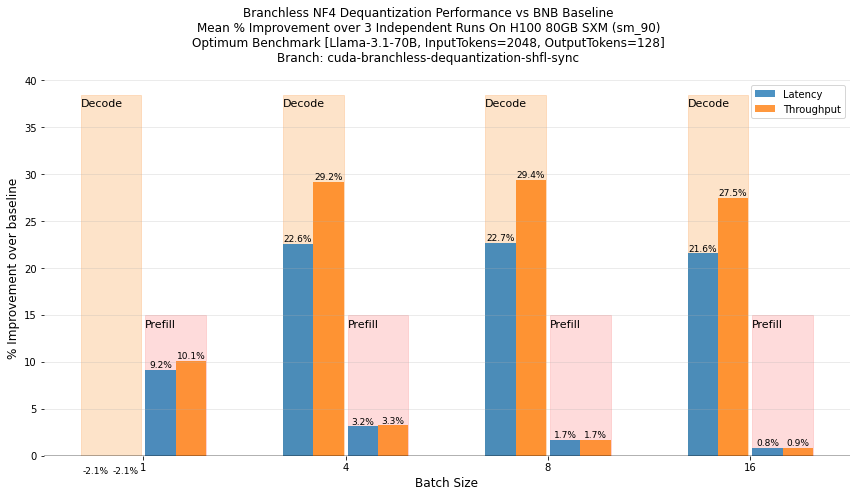

In [12]:
def plot_summary_histogram(plot_df, n_runs):
    groups = plot_df.groupby("index")
    group_list = list(groups)

    batch_sizes = plot_df['batch_size'].unique()
    fig, ax = plt.subplots(figsize=(12, 7))

    bar_width = 0.15
    group_spacing = 0.02
    y_axis_range = (0, 40)
    y_axis_length = abs(y_axis_range[1] - y_axis_range[0])

    # latency, throughput
    colors = ["#1f77b4", "#ff7f0e"]
    
    # prefill, decode
    shading = ["#FDB0B0", "#FCC189"]
    x_pos = np.arange(len(batch_sizes))

    for group_idx, (key, group) in enumerate(group_list):
        group_offset = (group_idx - (len(group_list)-1)/2) * (bar_width * 2 + group_spacing)
        
        latency_vals, throughput_vals = [], []
        
        for batch_size in batch_sizes:
            batch_data = group[group['batch_size'] == batch_size]
            latency_vals.append(batch_data['latency_mean_diff_%'].iloc[0])
            throughput_vals.append(batch_data['throughput_value_diff_%'].iloc[0])

        lat_pos = x_pos + group_offset - bar_width/2
        thr_pos = x_pos + group_offset + bar_width/2
        
        bars_lat = list(ax.bar(lat_pos, latency_vals, bar_width, color=colors[0],
                        label='Latency' if group_idx == 0 else "", alpha=0.8))
        bars_thr = list(ax.bar(thr_pos, throughput_vals, bar_width, color=colors[1],
                        label='Throughput' if group_idx == 0 else "", alpha=0.8))

        for bar in bars_lat+ bars_thr:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f"{height:.1f}%", ha='center', va='bottom', fontsize=9, color='black')

        for i, x in enumerate(lat_pos):
            xmin = x - bars_thr[i].get_width() * 0.5
            xmax = x + bars_thr[i].get_width() * 1.5
            height = (.96, 37) if key == 'decode' else (0.375, 13.5)
            color = shading[key == 'decode']
            ax.axvspan(xmin, xmax, 0/y_axis_length, height[0], alpha=0.45, zorder=0, color=color)
            ax.text(xmin, height[1], key.capitalize(), ha='left', va='bottom', fontsize=11)

    ax.set_ylim(*y_axis_range)
    ax.set_ylabel('% Improvement over baseline', fontsize=12)

    entry = plot_df.iloc[0]
    model_name = entry["model"]
    input_size = entry["input_size"]
    output_size = entry["output_size"]
    output_size = entry["output_size"]

    # share x-axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{bs}' for bs in batch_sizes])
    ax.set_xlabel('Batch Size', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)

    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    plt.suptitle(
        f"Branchless NF4 Dequantization Performance vs BNB Baseline\n"
        f"Mean % Improvement over {n_runs} Independent Runs On H100 80GB SXM (sm_90)\n"
        f"Optimum Benchmark [{model_name}, InputTokens={input_size}, OutputTokens={output_size}]"
        f"\nBranch: {OTHER_BRANCH}"
        ,fontsize=12
    )
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()
    return fig

run_ids = diff.reset_index()["run"].unique()
plot_df = run_agg_diff.reset_index()
fig = plot_summary_histogram(plot_df, len(run_ids))
fig.savefig("H100_Inference_Benchmark.png", dpi=300, bbox_inches='tight', facecolor='white')
plot_df.to_csv("plot_diff.csv", index=False)

Observations:
 - For decode, for batch sizes greater than 1, throughput is improved by ~28% and latency is reduced by ~22%.
 - For prefill, throughput is improved by ~10% and latency is reduced by ~9% when the batch size is 1. The effect diminishes with larger batch sizes so further investigation may be needed here.

### H100 NF4 Custom Stress Test

#### Stress Test Results

In [13]:
MEASURE = "total"
METRICS = [f"quantize_dequantize_latency_{MEASURE}", f"quantize_latency_{MEASURE}", f"dequantize_latency_{MEASURE}"]

In [14]:
runs = os.listdir(data_path)
dfs = []
for run_id in runs:
    if not os.path.isdir(os.path.join(data_path,run_id)): continue
    branches = os.path.join(data_path, run_id)
    for branch in os.listdir(branches):
        branch_data_path = os.path.join(data_path, run_id, branch, "stress_test_run.csv")
        if not os.path.exists(branch_data_path): continue
        branch_df = pd.read_csv(branch_data_path)
        branch_df["branch"] = branch
        branch_df["run"] = run_id
        dfs.append(branch_df)

# any column would do the trick
lookup = "quantize_dequantize_latency_"
N_STRESS_TEST_ITERATIONS = branch_df.iloc[0][lookup+"count"]
print("Iterations:", N_STRESS_TEST_ITERATIONS)

data_df = pd.concat(dfs)
data_df = data_df.groupby(["run", "dtype", "quant_type", "branch",  "blocksize", "tensor_shape"])[METRICS].first().sort_index()
DTYPE = "torch.float32"
QUANT_TYPE = "nf4"
RUN_ID = "run_1"
data_df = data_df.xs(RUN_ID, level=0)
data_df = data_df.xs(DTYPE, level=0)
data_df = data_df.xs(QUANT_TYPE, level=0)
data_df

Iterations: 1000


quantize_dequantize_latency_total  \
branch                                   blocksize tensor_shape                                      
cuda-branchless-dequantization-shfl-sync 64        1024                                  79.878752   
                                                   2048                                 110.380352   
                                                   4096                                 244.089344   
                                                   8192                                 795.932192   
                                                   16384                               3014.510463   
main                                     64        1024                                  79.166560   
                                                   2048                                 110.403264   
                                                   4096                                 259.284128   
                                                   8192                                 855.163487   
                                                   16384                               3237.647490   

                                                                 quantize_latency_total  \
branch                                   blocksize tensor_shape                           
cuda-branchless-dequantization-shfl-sync 64        1024                       53.629024   
                                                   2048                       82.413408   
                                                   4096                      201.008160   
                                                   8192                      674.672480   
                                                   16384                    2571.370784   
main                                     64        1024                       53.893504   
                                                   2048                       83.399648   
                                                   4096                      201.633536   
                                                   8192                      677.471488   
                                                   16384                    2572.729727   

                                                                 dequantize_latency_total  
branch                                   blocksize tensor_shape                            
cuda-branchless-dequantization-shfl-sync 64        1024                          6.580480  
                                                   2048                         10.330880  
                                                   4096                         32.347968  
                                                   8192                        111.599840  
                                                   16384                       427.586144  
main                                     64        1024                          8.489696  
                                                   2048                         15.577440  
                                                   4096                         46.937248  
                                                   8192                        168.673792  
                                                   16384                       649.694080

In [15]:
data_df.reset_index()["branch"].unique().tolist()

['cuda-branchless-dequantization-shfl-sync', 'main']

In [16]:
stress_test_baseline = data_df.xs(BASELINE_BRANCH, level=0)
stress_test_improved = data_df.xs(OTHER_BRANCH, level=0)
assert (stress_test_baseline.index.equals(stress_test_improved.index))
stress_diff = (stress_test_baseline-stress_test_improved)/stress_test_baseline * 100
stress_diff = stress_diff.add_suffix("_%")
stress_diff

quantize_dequantize_latency_total_%  \
blocksize tensor_shape                                        
64        1024                                    -0.899612   
          2048                                     0.020753   
          4096                                     5.860283   
          8192                                     6.926312   
          16384                                    6.891949   

                        quantize_latency_total_%  dequantize_latency_total_%  
blocksize tensor_shape                                                        
64        1024                          0.490746                   22.488626  
          2048                          1.182547                   33.680503  
          4096                          0.310155                   31.082521  
          8192                          0.413155                   33.836882  
          16384                         0.052821                   34.186541

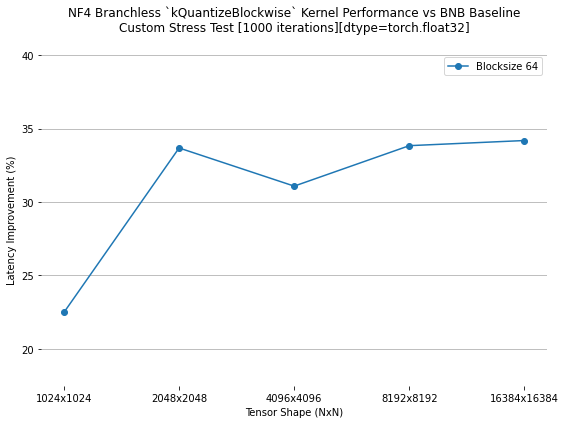

In [17]:
def plot(diff, column, kernel_name):
    d = diff.reset_index()
    d["dim"] = d["tensor_shape"]
    d["tensor_shape"] = d["dim"] ** 2

    # start plot
    fig, ax = plt.subplots(figsize=(8, 6))
    max_v, min_v = -100, 100
    for blocksize, subdf in d.groupby("blocksize"):
        ax.plot(
            list(range(subdf[column].shape[0])),
            subdf[column].values,
            marker="o",
            label=f"Blocksize {blocksize}"
        )
        min_v = min(min_v, subdf[column].min())
        max_v = max(max_v, subdf[column].max())

    # custom ticks
    # tickvals = d["tensor_shape"].unique()
    ticktext = [f"{dim}x{dim}" for dim in d["dim"].unique()]
    # ax.set_xscale("log")
    ax.set_xticks(range(subdf[column].shape[0]))
    ax.set_xticklabels(ticktext)#, rotation=45, ha="right")
    # print(ticktext)

    # labels and title
    ax.set_xlabel("Tensor Shape (NxN)")
    ax.set_ylabel("Latency Improvement (%)")
    ax.set_title(
        f"NF4 Branchless `{kernel_name}` Kernel Performance vs BNB Baseline\n"
        f"Custom Stress Test [{N_STRESS_TEST_ITERATIONS} iterations][dtype={DTYPE}]\n"
    )
    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    ax.grid(True, axis='x', alpha=0.2)
    ax.set_ylim(min_v-5, max_v+6)
    plt.tight_layout()
    plt.grid()
    plt.legend(loc="upper right")
    plt.show()

# plot(diff, f"quantize_latency_{MEASURE}_%", "")
# plot(diff, f"quantize_dequantize_latency_{MEASURE}_%", "")
plot(stress_diff, f"dequantize_latency_{MEASURE}_%", "kQuantizeBlockwise")

#### NCU Results

In [18]:
METRICS_TO_KEEP = [
    "gpu__time_duration_measured_user.avg",
    "smsp__sass_branch_targets_threads_divergent.sum",
    "sm__throughput.avg.pct_of_peak_sustained_elapsed",
    "dram__throughput.avg.pct_of_peak_sustained_elapsed",
]

In [19]:
def load_ncu_metadata(path, csv_name="stress_test_ncu_metadata.csv"):
    branches = os.listdir(path)
    dfs = []
    for branch in branches:
        branch_data_path = os.path.join(path, branch, csv_name)
        if not os.path.exists(branch_data_path): continue
        metadata = pd.read_csv(branch_data_path)
        metadata["branch"] = branch
        if dfs: assert(dfs[-1].shape == metadata.shape)
        dfs.append(metadata)
    return pd.concat(dfs)

run_id = "run_1"
ncu_data_path = os.path.join(data_path, run_id)
ncu_metadata_df = load_ncu_metadata(ncu_data_path)
ncu_metadata_df

,access_pattern,tensor_shape,blocksize,quant_type,dtype,is_warmup,branch
0,NaN,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-shfl-sync
1,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-shfl-sync
2,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-shfl-sync
3,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-shfl-sync
4,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-shfl-sync
...,...,...,...,...,...,...,...
2200,interleaved,16384,64,nf4,torch.float32,False,main
2201,interleaved,16384,64,nf4,torch.float32,False,main
2202,interleaved,16384,64,nf4,torch.float32,False,main
2203,interleaved,16384,64,nf4,torch.float32,False,main


In [20]:
ncu_metadata_df["branch"].unique().tolist()

['cuda-branchless-dequantization-shfl-sync', 'main']

In [21]:
def load_ncu_csv(path, ncu_metadata_df, csv_name="ncu_rep.csv", keep_units=False):
    dfs = []
    for branch in os.listdir(path):
        branch_path = os.path.join(path, branch, csv_name)
        if not os.path.exists(branch_path): continue
        df = pd.read_csv(branch_path)
        df["KernelName"] = df["Kernel Name"].apply(lambda x: str(x).split("<")[0].replace("void", "").strip())
        df = df[["KernelName"] + METRICS_TO_KEEP]
        if not keep_units:
            df = df.iloc[1:].reset_index(drop=True)
            # convert from microseconds to seconds
            df["gpu__time_duration_measured_user.avg"] = df["gpu__time_duration_measured_user.avg"].astype(float) * 1e-6
        branch_mask = ncu_metadata_df["branch"]==branch
        assert branch_mask.sum() == df.shape[0], f"Shape mismatch: {branch_mask.sum()} vs {df.shape[0]}"
        df["Blocksize"] = ncu_metadata_df[branch_mask]["blocksize"]
        df["QuantType"] = ncu_metadata_df[branch_mask]["quant_type"]
        df["TensorShape"] = ncu_metadata_df[branch_mask]["tensor_shape"]
        for col in METRICS_TO_KEEP:
            df[col] = df[col].apply(lambda x: str(x).replace(",", "")).astype(float)
        df["Branch"] = branch
        df["Warmup?"] = ncu_metadata_df[branch_mask]["is_warmup"]
        df["AccessPattern"] = ncu_metadata_df[branch_mask]["access_pattern"]
        # df["AccessPattern"] = "missing"
        df = df[df["Warmup?"]==False].drop(columns=["Warmup?"])
        # df = df.reset_index().groupby(["QuantType", "Branch", "TensorShape", "Blocksize", "KernelName"])[METRICS_TO_KEEP].apply(add_access_pattern)
        # df = df.reset_index().drop(columns="level_5")
        group = ["QuantType", "Branch", "Blocksize", "TensorShape", "KernelName", "AccessPattern"]
        df = df.groupby(group).sum()
        df = df.reset_index()
        if dfs:
            assert dfs[-1].shape[0] == df.shape[0], f"Shape mismatch: {dfs[-1].shape} vs {df.shape}"
        dfs.append(df)
    return pd.concat(dfs).set_index(group)

ncu_df = load_ncu_csv(ncu_data_path, ncu_metadata_df)
ncu_df

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\4221224124.py:6: DtypeWarning: Columns (179,180,181,182,183,184,185,186,187,189,190,191,196,197,209,210,211,212,213,214,215,221,222,223,224,225,226,227,228,229,232,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(branch_path)
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\4221224124.py:6: DtypeWarning: Columns (179,180,181,182,183,184,185,186,187,189,190,191,196,197,209,210,211,212,213,214,215,221,222,223,224,225,226,227,228,229,232,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(branch_path)


gpu__time_duration_measured_user.avg  \
QuantType Branch                                   Blocksize TensorShape KernelName           AccessPattern                                         
nf4       cuda-branchless-dequantization-shfl-sync 64        1024        kDequantizeBlockwise interleaved                            5.608800e-07   
                                                                                              sequential                             5.647390e-07   
                                                                         kQuantizeBlockwise   interleaved                            1.393203e-06   
                                                                                              sequential                             1.392186e-06   
                                                             2048        kDequantizeBlockwise interleaved                            1.011445e-06   
                                                                                              sequential                             1.013449e-06   
                                                                         kQuantizeBlockwise   interleaved                            4.345589e-06   
                                                                                              sequential                             4.349624e-06   
                                                             4096        kDequantizeBlockwise interleaved                            2.996981e-06   
                                                                                              sequential                             2.996425e-06   
                                                                         kQuantizeBlockwise   interleaved                            1.616711e-05   
                                                                                              sequential                             1.615363e-05   
                                                             8192        kDequantizeBlockwise interleaved                            1.084568e-05   
                                                                                              sequential                             1.086207e-05   
                                                                         kQuantizeBlockwise   interleaved                            6.338829e-05   
                                                                                              sequential                             6.342116e-05   
                                                             16384       kDequantizeBlockwise interleaved                            4.232455e-05   
                                                                                              sequential                             4.230941e-05   
                                                                         kQuantizeBlockwise   interleaved                            2.524454e-04   
                                                                                              sequential                             2.524537e-04   
          main                                     64        1024        kDequantizeBlockwise interleaved                            7.812090e-07   
                                                                                              sequential                             7.831610e-07   
                                                                         kQuantizeBlockwise   interleaved                            1.392498e-06   
                                                                                              sequential                             1.392781e-06   
                                                             2048        kDequantizeBlockwise interleaved                            1.603373e-06   
                                                                                      

In [22]:
ncu_baseline = ncu_df.xs(BASELINE_BRANCH, level=1)
ncu_improved = ncu_df.xs(OTHER_BRANCH, level=1)

ncu_diff = (ncu_baseline-ncu_improved)/ncu_baseline * 100
ncu_diff = ncu_diff.add_suffix("_%")
ncu_diff

gpu__time_duration_measured_user.avg_%  \
QuantType Blocksize TensorShape KernelName           AccessPattern                                           
nf4       64        1024        kDequantizeBlockwise interleaved                                 28.203592   
                                                     sequential                                  27.889795   
                                kQuantizeBlockwise   interleaved                                 -0.050628   
                                                     sequential                                   0.042720   
                    2048        kDequantizeBlockwise interleaved                                 36.917673   
                                                     sequential                                  36.794145   
                                kQuantizeBlockwise   interleaved                                  0.059381   
                                                     sequential                                  -0.051663   
                    4096        kDequantizeBlockwise interleaved                                 41.062436   
                                                     sequential                                  41.042460   
                                kQuantizeBlockwise   interleaved                                 -0.019680   
                                                     sequential                                   0.062078   
                    8192        kDequantizeBlockwise interleaved                                 42.645431   
                                                     sequential                                  42.565828   
                                kQuantizeBlockwise   interleaved                                  0.047392   
                                                     sequential                                  -0.006210   
                    16384       kDequantizeBlockwise interleaved                                 42.919014   
                                                     sequential                                  42.948758   
                                kQuantizeBlockwise   interleaved                                 -0.007508   
                                                     sequential                                  -0.012633   

                                                                    smsp__sass_branch_targets_threads_divergent.sum_%  \
QuantType Blocksize TensorShape KernelName           AccessPattern                                                      
nf4       64        1024        kDequantizeBlockwise interleaved                                            68.695546   
                                                     sequential                                             68.695546   
                                kQuantizeBlockwise   interleaved                                             0.000000   
                                                     sequential                                              0.000000   
                    2048        kDequantizeBlockwise interleaved                                            68.693392   
                                                     sequential                                             68.693392   
                                kQuantizeBlockwise   interleaved                                             0.000000   
                                                     sequential                                              0.000000   
                    4096        kDequantizeBlockwise interleaved                                            68.694230   
                                                     sequential                                             68.694230   
                                kQuantizeBlockwise   interleaved                                             0.000000   
                                                     sequential           

In [23]:
# agg on all access patterns
ncu_diff_agg = ncu_diff.reset_index().groupby(["QuantType", "Blocksize", "TensorShape", "KernelName"])[ncu_diff.columns].mean()

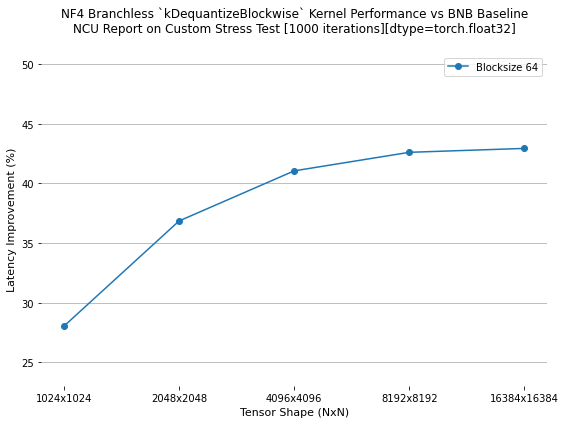

In [24]:
def plot(diff, column, kernel_name):
    d = diff.reset_index()
    d = d[d["KernelName"]==kernel_name]
    d["dim"] = d["TensorShape"]
    d["tensor_shape"] = d["dim"] ** 2

    # start plot
    fig, ax = plt.subplots(figsize=(8, 6))
    max_v, min_v = -100, 100
    for blocksize, subdf in d.groupby("Blocksize"):
        ax.plot(
            list(range(subdf[column].shape[0])),
            subdf[column].values,
            marker="o",
            label=f"Blocksize {blocksize}"
        )
        min_v = min(min_v, subdf[column].min())
        max_v = max(max_v, subdf[column].max())

    # custom ticks
    # tickvals = d["tensor_shape"].unique()
    ticktext = [f"{dim}x{dim}" for dim in d["dim"].unique()]
    # ax.set_xscale("log")
    ax.set_xticks(range(subdf[column].shape[0]))
    ax.set_xticklabels(ticktext)#, rotation=45, ha="right")
    # print(ticktext)

    # labels and title
    ax.set_xlabel("Tensor Shape (NxN)", fontsize=11)
    ax.set_ylabel("Latency Improvement (%)", fontsize=11)
    ax.set_title(
        f"NF4 Branchless `{kernel_name}` Kernel Performance vs BNB Baseline\n"
        f"NCU Report on Custom Stress Test [{N_STRESS_TEST_ITERATIONS} iterations][dtype={DTYPE}]\n"
    )
    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    ax.grid(True, axis='x', alpha=0.2)
    ax.set_ylim(min_v-5, max_v+8)
    plt.tight_layout()
    plt.grid()
    plt.legend(loc="upper right")
    plt.show()

plot(ncu_diff_agg, f"gpu__time_duration_measured_user.avg_%", "kDequantizeBlockwise")

~~Merge NCU report plot with Custom stress test plot and discard block sizes since the performance difference is negligible and currently there is no direct way to set the quantization blocksize from BNB quantization settings (its not exposed in transformers yet)~~ different block sizes were not tested for shfl-sync branch.

#### Custom Stress Test + NCU Report

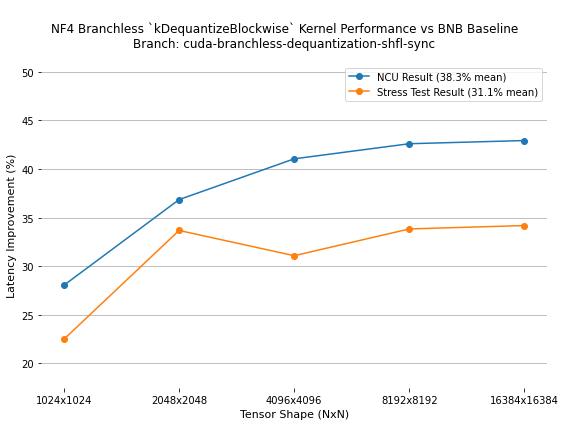

In [25]:
def plot(ncu_df, ncu_column, stress_df, stress_column, kernel_name, blocksize=64):
    df = ncu_df.reset_index()
    df = df[df["KernelName"]==kernel_name]

    # start plot
    fig, ax = plt.subplots(figsize=(8, 6))
    max_v, min_v = -100, 100
    df = df[df["Blocksize"]==blocksize]
    ncu_mean = df[ncu_column].mean()
    ax.plot(
        list(range(df[ncu_column].shape[0])),
        df[ncu_column].values,
        marker="o",
        label=f"NCU Result ({ncu_mean:.1f}% mean)"
    )
    min_v = min(min_v, df[ncu_column].min())
    max_v = max(max_v, df[ncu_column].max())
    df = stress_df.reset_index()
    df = df[df["blocksize"]==blocksize]
    stress_test_mean = df[stress_column].mean()
    ax.plot(
        list(range(df[stress_column].shape[0])),
        df[stress_column].values,
        marker="o",
        label=f"Stress Test Result ({stress_test_mean:.1f}% mean)"
    )
    min_v = min(min_v, df[stress_column].min())
    max_v = max(max_v, df[stress_column].max())
    df["dim"] = df["tensor_shape"]
    df["tensor_shape"] = df["dim"] ** 2

    # custom ticks
    # tickvals = d["tensor_shape"].unique()
    ticktext = [f"{dim}x{dim}" for dim in df["dim"].unique()]
    # ax.set_xscale("log")
    ax.set_xticks(range(df[stress_column].shape[0]))
    ax.set_xticklabels(ticktext)#, rotation=45, ha="right")
    # print(ticktext)

    # labels and title
    ax.set_xlabel("Tensor Shape (NxN)", fontsize=11)
    ax.set_ylabel("Latency Improvement (%)", fontsize=11)
    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    # ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    # ax.axhline(y=ncu_mean, color='blue', linestyle='--', alpha=.4, label=f"NCU Mean ({ncu_mean:.1f}%)")
    # ax.axhline(y=stress_test_mean, color='orange', linestyle='--', alpha=.4, label=f"Stress Test Mean ({stress_test_mean:.1f}%)")
    ax.grid(True, axis='x', alpha=0.2)
    ax.set_ylim(min_v-5, max_v+8)
    fig.suptitle(
        # f"NCU Results Vs Custom Stress Test Results\n"
        f"\nNF4 Branchless `{kernel_name}` Kernel Performance vs BNB Baseline"
        f"\nBranch: {OTHER_BRANCH}"
    )
    plt.tight_layout()
    plt.grid()
    plt.legend(loc="upper right")
    plt.show()
    return fig

fig = plot(ncu_diff_agg, f"gpu__time_duration_measured_user.avg_%", stress_diff, f"dequantize_latency_{MEASURE}_%", "kDequantizeBlockwise")
fig.savefig("stress_test_plot.png", dpi=300, bbox_inches='tight', facecolor='white')

Observation: 
- Stress test (torch.cuda.Event): ~30% latency reduction.
- Kernel-level speedup (NCU on stress test): ~38% latency reduction.

#### Conclusion

Benchmark results for Llama-3.1-70B on H100 80GB SXM (sm_90):
- Improved decode throughput by ~28% and reduced latency by ~22% for batch sizes > 1.
- Improved prefill throughput by ~10% and reduced latency by ~9% for batch size 1.
- Reduced dequantization latency for NF4 by ~38% overall.